<a href="https://colab.research.google.com/github/PJ40200/Autonomous-Tagging-for-Stack-Overflow-Questions/blob/main/Autonomous_Question_Tagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download('stackoverflow/stacksample')

Using Colab cache for faster access to the 'stacksample' dataset.


In [ ]:
path

'/kaggle/input/stacksample'

In [ ]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv(f"{path}/Questions.csv", encoding="ISO-8859-1")
tags = pd.read_csv(f"{path}/Tags.csv", encoding="ISO-8859-1", dtype={'Tag': str})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1264216 entries, 0 to 1264215
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Id            1264216 non-null  int64  
 1   OwnerUserId   1249762 non-null  float64
 2   CreationDate  1264216 non-null  object 
 3   ClosedDate    55959 non-null    object 
 4   Score         1264216 non-null  int64  
 5   Title         1264216 non-null  object 
 6   Body          1264216 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 67.5+ MB


In [ ]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750994 entries, 0 to 3750993
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   Id      int64 
 1   Tag     object
dtypes: int64(1), object(1)
memory usage: 57.2+ MB


In [ ]:
df.head(5)

,Id,OwnerUserId,CreationDate,ClosedDate,Score,Title,Body
0,80,26.0,2008-08-01T13:57:07Z,NaN,26,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...
1,90,58.0,2008-08-01T14:41:24Z,2012-12-26T03:45:49Z,144,Good branching and merging tutorials for Torto...,<p>Are there any really good tutorials explain...
2,120,83.0,2008-08-01T15:50:08Z,NaN,21,ASP.NET Site Maps,<p>Has anyone got experience creating <strong>...
3,180,2089740.0,2008-08-01T18:42:19Z,NaN,53,Function for creating color wheels,<p>This is something I've pseudo-solved many t...
4,260,91.0,2008-08-01T23:22:08Z,NaN,49,Adding scripting functionality to .NET applica...,<p>I have a little game written in C#. It uses...


In [ ]:
tags.head(5)

,Id,Tag
0,80,flex
1,80,actionscript-3
2,80,air
3,90,svn
4,90,tortoisesvn


In [ ]:
tags['Tag'] = tags['Tag'].astype(str)
grouped_tags = tags.groupby("Id")['Tag'].apply(lambda tags: ' '.join(tags))

In [ ]:
grouped_tags.reset_index()
grouped_tags.head(5)

,Tag
Id,
80,flex actionscript-3 air
90,svn tortoisesvn branch branching-and-merging
120,sql asp.net sitemap
180,algorithm language-agnostic colors color-space
260,c# .net scripting compiler-construction


In [ ]:
df_tags = pd.DataFrame({'Id' : grouped_tags.index, 'Tags' : grouped_tags.values})
df_tags.head(5)

,Id,Tags
0,80,flex actionscript-3 air
1,90,svn tortoisesvn branch branching-and-merging
2,120,sql asp.net sitemap
3,180,algorithm language-agnostic colors color-space
4,260,c# .net scripting compiler-construction


In [ ]:
df_tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1264216 entries, 0 to 1264215
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   Id      1264216 non-null  int64 
 1   Tags    1264216 non-null  object
dtypes: int64(1), object(1)
memory usage: 19.3+ MB


In [ ]:
# delete the unwanted columns from the Questions dataset
df.drop(columns=['OwnerUserId', 'CreationDate', 'ClosedDate'], inplace=True)

In [ ]:
df = df.merge(df_tags, on='Id')
df.head()

,Id,Score,Title,Body,Tags
0,80,26,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...,flex actionscript-3 air
1,90,144,Good branching and merging tutorials for Torto...,<p>Are there any really good tutorials explain...,svn tortoisesvn branch branching-and-merging
2,120,21,ASP.NET Site Maps,<p>Has anyone got experience creating <strong>...,sql asp.net sitemap
3,180,53,Function for creating color wheels,<p>This is something I've pseudo-solved many t...,algorithm language-agnostic colors color-space
4,260,49,Adding scripting functionality to .NET applica...,<p>I have a little game written in C#. It uses...,c# .net scripting compiler-construction


#Data Preparation

We are taking only the 100 most frequent tags out of all tags for better tag prediction as large number of tags can act as noise and reduce our accuracy

In [ ]:
df['Tags'] = df['Tags'].apply(lambda x: x.split())
all_tags = [item for sublist in df['Tags'].values for item in sublist]
my_set = set(all_tags)
unique_tags = list(my_set)
len(unique_tags)

flat_list = [item for sublist in df['Tags'].values for item in sublist]

keywords = nltk.FreqDist(flat_list)

keywords = nltk.FreqDist(keywords)

frequencies_words = keywords.most_common(100)
tags_features = [word[0] for word in frequencies_words]

In [ ]:
import matplotlib.pyplot as plt

<Axes: xlabel='Samples', ylabel='Counts'>

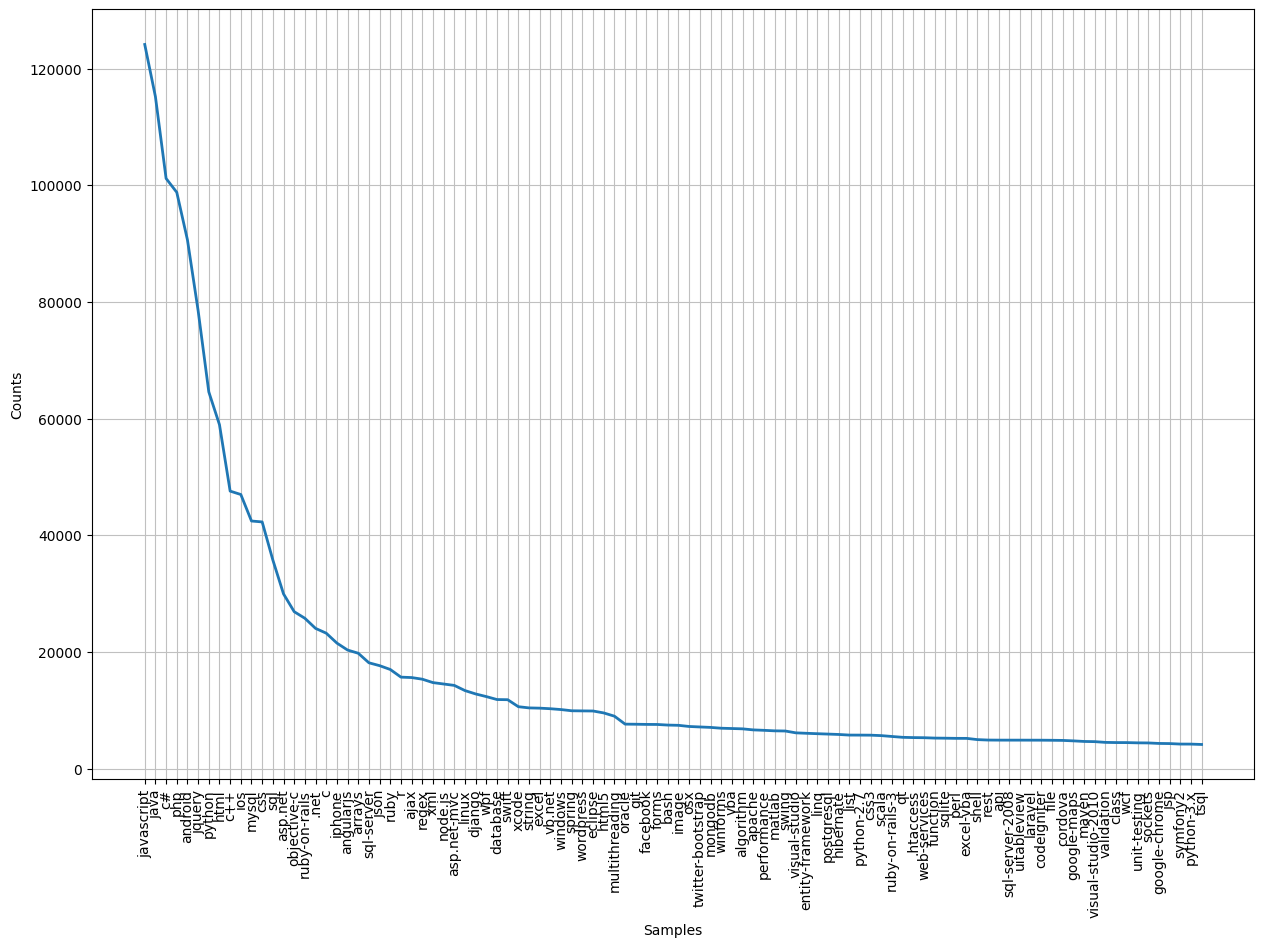

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
keywords.plot(100, cumulative=False)

In [ ]:
def most_common(tags):
    tags_filtered = []
    for i in range(0, len(tags)):
        if tags[i] in tags_features:
            tags_filtered.append(tags[i])
    return tags_filtered

In [ ]:
df['Tags'] = df['Tags'].apply(lambda x: most_common(x))
df['Tags'] = df['Tags'].apply(lambda x: x if len(x)>0 else None)

In [ ]:
df.shape

(1264216, 5)

In [ ]:
df.dropna(subset=['Tags'], inplace=True)

In [ ]:
df.shape

(1057478, 5)

In [ ]:
df.head()

,Id,Score,Title,Body,Tags
2,120,21,ASP.NET Site Maps,<p>Has anyone got experience creating <strong>...,"[sql, asp.net]"
3,180,53,Function for creating color wheels,<p>This is something I've pseudo-solved many t...,[algorithm]
4,260,49,Adding scripting functionality to .NET applica...,<p>I have a little game written in C#. It uses...,"[c#, .net]"
5,330,29,Should I use nested classes in this case?,<p>I am working on a collection of classes use...,"[c++, class]"
6,470,13,Homegrown consumption of web services,<p>I've been writing a few web services for a ...,"[.net, web-services]"


Since the score value is negative too. We filter out those values and take only the positive ones and since the majority of the values are concentrated in the 0-500 range. We take only those values to avoid imbalance.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1057478 entries, 2 to 1264214
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   Id      1057478 non-null  int64 
 1   Score   1057478 non-null  int64 
 2   Title   1057478 non-null  object
 3   Body    1057478 non-null  object
 4   Tags    1057478 non-null  object
dtypes: int64(2), object(3)
memory usage: 48.4+ MB


In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import ToktokTokenizer

In [ ]:
from bs4 import BeautifulSoup
# Converting html to text in the body
df['Body'] = df['Body'].apply(lambda x: BeautifulSoup(x).get_text())

def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)
    text = re.sub(r"\'\n", " ", text)
    text = re.sub(r"\'\xa0", " ", text)
    text = text.strip(' ')
    return text

df['Body'] = df['Body'].apply(lambda x : clean_text(x))

In [ ]:
token=ToktokTokenizer()
stop_words = set(stopwords.words("english"))

def stopWordsRemove(text):

    stop_words = set(stopwords.words("english"))

    words=token.tokenize(text)

    filtered = [w for w in words if not w in stop_words]

    return ' '.join(map(str, filtered))

df['Body'] = df['Body'].apply(lambda x: stopWordsRemove(x))

In [ ]:
# Combine title + body
df['text'] = df['Title'] + " " + df['Body']

In [ ]:
# drop the Title and Body column and they have been joined in the text column
df.drop(columns=['Title', 'Body'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1057478 entries, 2 to 1264214
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   Id      1057478 non-null  int64 
 1   Score   1057478 non-null  int64 
 2   Tags    1057478 non-null  object
 3   text    1057478 non-null  object
dtypes: int64(2), object(2)
memory usage: 40.3+ MB


Filtering Score values

In [ ]:
df['Score'].min()

-73

In [ ]:
df['Score'].max()

5190

In [ ]:
df['Score'].value_counts()

,count
Score,
0,491690
1,232853
2,104141
3,50923
-1,38797
...,...
568,1
472,1
-20,1


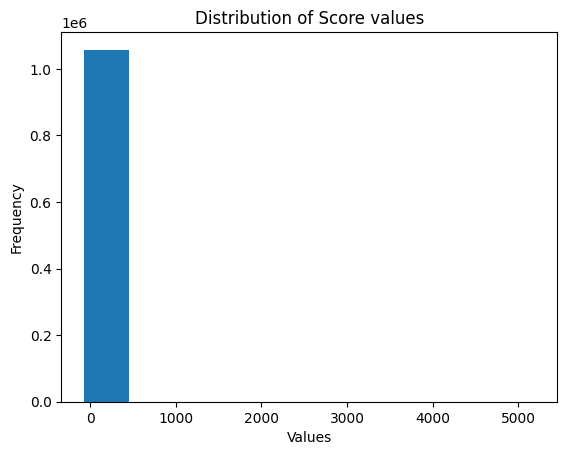

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Score'])
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of Score values')
plt.show()

In [ ]:
data = df[(df['Score']>=0) & (df['Score']<500)]

# Data Cleaning

In [ ]:
print('Null entries: {}'.format(data.isnull().sum()))

Null entries: Id       0
Score    0
Tags     0
text     0
dtype: int64


In [ ]:
data.drop(columns=['Id', 'Score'], inplace=True)

/tmp/ipykernel_6100/3369642163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['Id', 'Score'], inplace=True)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 986292 entries, 2 to 1264214
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Tags    986292 non-null  object
 1   text    986292 non-null  object
dtypes: object(2)
memory usage: 22.6+ MB


In [ ]:
data.head(5)

,Tags,text
2,"[sql, asp.net]",ASP.NET Site Maps anyone got experience creati...
3,[algorithm],Function for creating color wheels something p...
4,"[c#, .net]",Adding scripting functionality to .NET applica...
5,"[c++, class]",Should I use nested classes in this case? work...
6,"[.net, web-services]",Homegrown consumption of web services writing ...


Checking the number of unique tags

In [ ]:
all_tags = [item for sublist in data['Tags'].values for item in sublist]
len(all_tags)

1633858

In [ ]:
my_set = set(all_tags)
unique_tags = list(my_set)
len(unique_tags)

100

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
no_topics = 20
topics_number = len(unique_tags)
vectorizer_train = TfidfVectorizer(analyzer = 'word',
                                       min_df=0.0,
                                       max_df = 1.0,
                                       strip_accents = None,
                                       encoding = 'utf-8',
                                       preprocessor=None,
                                       token_pattern=r"(?u)\S\S+", # Need to repeat token pattern
                                       max_features=1000)

TF_IDF_matrix = vectorizer_train.fit_transform(data['text'])
lda = LatentDirichletAllocation(n_components=no_topics, max_iter=5, learning_method='online', learning_offset=50,random_state=11).fit(TF_IDF_matrix)

In [ ]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("--------------------------------------------")
        print("Topic %d:" % (topic_idx))
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print("--------------------------------------------")


no_top_words = 10
display_topics(lda, vectorizer_train.get_feature_names_out(), no_top_words)

--------------------------------------------
Topic 0:
string print regex word printf line text str characters expression
--------------------------------------------
--------------------------------------------
Topic 1:
function var console.log echo return func ?> error array value
--------------------------------------------
--------------------------------------------
Topic 2:
date studio visual month service application windows mobile phone year
--------------------------------------------
--------------------------------------------
Topic 3:
error file run command import install -- python line version
--------------------------------------------
--------------------------------------------
Topic 4:
&#124; table select query column row sql id 00 join
--------------------------------------------
--------------------------------------------
Topic 5:
public new string void class int private return import null
--------------------------------------------
--------------------------------

* Binarize the tags
* Use a TFIDF for body and Title

In [ ]:
X = data['text']
y = data['Tags']

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

multilabel_binarizer = MultiLabelBinarizer()
y_bin = multilabel_binarizer.fit_transform(y)

In [ ]:
vectorizer_X = TfidfVectorizer(analyzer = 'word',
                                       min_df=0.0,
                                       max_df = 1.0,
                                       strip_accents = None,
                                       encoding = 'utf-8',
                                       preprocessor=None,
                                       token_pattern=r"(?u)\S\S+",
                                       max_features=1000)

X_tfidf = vectorizer_X.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_bin, test_size = 0.2, random_state = 0)

# Classification

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.metrics import hamming_loss

from sklearn import model_selection

In [ ]:
def print_score(y_pred, clf):
    print("Classifier : ", clf.__class__.__name__)
    print("Micro F1 score : {}".format(f1_score(y_test, y_pred, average='micro')))
    print("Hamming loss : {}".format(hamming_loss(y_pred, y_test)*100))
    print("---")

In [ ]:
sgd = SGDClassifier()
lr = LogisticRegression()
mn = MultinomialNB()
svc = LinearSVC()

for classifier in [sgd, lr, mn, svc]:
    clf = OneVsRestClassifier(classifier)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print_score(y_pred, classifier)


Classifier :  SGDClassifier
Micro F1 score : 0.4593450438193788
Hamming loss : 1.2268895208837112
---
Classifier :  LogisticRegression
Micro F1 score : 0.5621125251460775
Hamming loss : 1.1332765551888633
---
Classifier :  MultinomialNB
Micro F1 score : 0.32092598708351683
Hamming loss : 1.5010620554702192
---
Classifier :  LinearSVC
Micro F1 score : 0.5431092091791379
Hamming loss : 1.1333779447325598
---


Overall Pipeline :
Loading data -> Merge the Questions and Tags dataset -> Filter only the 100 most common tags -> Clean the questions' text, extract it from html tags and remove the stop words -> Take only positive score values and the ones less than 500 -> Use tf-idf vectorizer on text -> Use multilabel binarizer for Tags -> Split the data in train and test set -> Use MultiNomialNB, SGD, LinearSV and Logistic regression classifier
Conclusion - Logistic Regression performs the best for *tagging* the stackoverflow questions.